In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import learn2learn as l2l

In [4]:
class Generator(nn.Module):
    def __init__(self, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.data = nn.Parameter(torch.randn(seq_len))

    def forward(self):
        return self.data

    def visualize(self):
        with torch.no_grad():
            s = self.data.cpu().numpy()
        plt.figure(figsize=(30, 5))
        plt.plot(s, label='Generated Sequence', marker='o', markersize=3, color='blue')
        plt.xlabel("Time step")
        plt.ylabel("Value")
        plt.xlim(-5, self.seq_len + 5)
        plt.grid(True, alpha=0.3)
        plt.show()

In [5]:
class RNN(nn.Module):
    def __init__(self, hidden_size=16):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out)

In [6]:
class MLP(nn.Module):
    def __init__(self, input_size=1, window_size=10, hidden_size=32):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(window_size * input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x).unsqueeze(-1)

In [7]:
def normalized_mse_loss(pred, target, seq):
    mean_abs_seq = torch.mean(torch.abs(seq))
    if mean_abs_seq == 0:
        mean_abs_seq = 1e-8
    return F.mse_loss(pred, target) / mean_abs_seq

class MetaLearnerCompetitive:
    def __init__(self, generator, rnn_class, mlp_class, meta_lr=1e-3, 
                 inner_lr=0.01, inner_steps=5, window_size=10, reg_lambda=0.1, mlp_lambda=1,
                 mse_threshold=1e12):
        self.generator = generator
        self.window_size = window_size
        self.reg_lambda = reg_lambda
        self.mlp_lambda = mlp_lambda
        self.inner_steps = inner_steps
        self.mse_threshold = mse_threshold
        
        self.rnn_base = rnn_class()
        self.mlp_base = mlp_class(window_size=window_size)
        
        self.maml_rnn = l2l.algorithms.MAML(self.rnn_base, lr=inner_lr)
        self.maml_mlp = l2l.algorithms.MAML(self.mlp_base, lr=inner_lr)
        
        self.meta_optimizer = torch.optim.Adam(self.generator.parameters(), lr=meta_lr)
        
        self.meta_losses = []
        self.mse_rnn = []
        self.mse_mlp = []

    def reset_model(self, model):
        for layer in model.modules():
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()

    def meta_step(self):
        seq = self.generator()
        
        windows, targets = [], []
        for i in range(len(seq) - self.window_size):
            windows.append(seq[i : i + self.window_size])
            targets.append(seq[i + self.window_size])
        
        X = torch.stack(windows).unsqueeze(-1)
        Y = torch.stack(targets).unsqueeze(-1).unsqueeze(-1)

        indices = torch.randperm(X.shape[0])
        split = int(X.shape[0] * 0.7)
        train_idx = indices[:split]
        test_idx = indices[split:]
        
        x_train, y_train = X[train_idx], Y[train_idx]
        x_test, y_test = X[test_idx], Y[test_idx]

        self.reset_model(self.rnn_base)
        self.reset_model(self.mlp_base)

        learner_rnn = self.maml_rnn.clone()
        learner_mlp = self.maml_mlp.clone()

        for _ in range(self.inner_steps):
            p_rnn = learner_rnn(x_train)[:, -1:, :]
            l_rnn = F.mse_loss(p_rnn, y_train)
            learner_rnn.adapt(l_rnn)

        for _ in range(self.inner_steps):
            p_mlp = learner_mlp(x_train)
            l_mlp = F.mse_loss(p_mlp, y_train)
            learner_mlp.adapt(l_mlp)

        test_pred_rnn = learner_rnn(x_test)[:, -1:, :]
        test_pred_mlp = learner_mlp(x_test)

        test_loss_rnn = normalized_mse_loss(test_pred_rnn, y_test, seq)
        test_loss_mlp = normalized_mse_loss(test_pred_mlp, y_test, seq)

        test_mse_rnn = F.mse_loss(test_pred_rnn, y_test)
        test_mse_mlp = F.mse_loss(test_pred_mlp, y_test)

        if test_loss_rnn > self.mse_threshold or test_loss_mlp > self.mse_threshold:
            return None, None, True

        competitive_loss = test_loss_rnn - self.mlp_lambda * torch.log(test_loss_mlp + 1e-6)
        l1_reg = torch.sum(torch.abs(seq))
        total_meta_loss = competitive_loss + self.reg_lambda * l1_reg

        self.meta_optimizer.zero_grad()
        total_meta_loss.backward()
        self.meta_optimizer.step()

        self.meta_losses.append(total_meta_loss.item())
        self.mse_rnn.append(test_mse_rnn.item())
        self.mse_mlp.append(test_mse_mlp.item())

        return test_mse_rnn.item(), test_mse_mlp.item(), False

    def train(self, steps, visualize_every=100):
        for step in range(steps):
            result = self.meta_step()
            if result[2]:
                print(f"Training stopped at step {step} because MSE exceeded threshold ({self.mse_threshold}).")
                break
            rnn_l, mlp_l, _ = result
            if visualize_every > 0 and step % visualize_every == 0 and step > 0:
                self.visualize_sequence()
                print(f"Step {step:4d} | RNN MSE: {rnn_l:.6f} | MLP MSE: {mlp_l:.6f}")

    def visualize_sequence(self):
        self.generator.visualize()

    def plot_mse(self, smoothing_window=10):
        if not self.mse_rnn:
            return
        plt.figure(figsize=(10, 4))
        def smooth(data, window):
            if len(data) < window:
                return data
            return np.convolve(data, np.ones(window)/window, mode='valid')
        
        plt.plot(self.mse_rnn, color='blue', alpha=0.3, label='RNN MSE (raw)')
        if len(self.mse_rnn) > smoothing_window:
            rnn_smooth = smooth(self.mse_rnn, smoothing_window)
            x = range(smoothing_window-1, len(self.mse_rnn))
            plt.plot(x, rnn_smooth, color='blue', linewidth=2, label='RNN MSE (smoothed)')
        
        plt.plot(self.mse_mlp, color='red', alpha=0.3, label='MLP MSE (raw)')
        if len(self.mse_mlp) > smoothing_window:
            mlp_smooth = smooth(self.mse_mlp, smoothing_window)
            x = range(smoothing_window-1, len(self.mse_mlp))
            plt.plot(x, mlp_smooth, color='red', linewidth=2, label='MLP MSE (smoothed)')
        
        plt.title("Test MSE")
        plt.xlabel("Meta-step")
        plt.ylabel("Mean Squared Error")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.yscale('log')
        plt.show()

    def plot_meta_loss(self, smoothing_window=10):
        if not self.meta_losses:
            return
        plt.figure(figsize=(10, 4))
        plt.plot(self.meta_losses, color='blue', alpha=0.3, label='Meta-loss (raw)')
        if len(self.meta_losses) > smoothing_window:
            data_smooth = np.convolve(self.meta_losses, np.ones(smoothing_window)/smoothing_window, mode='valid')
            plt.plot(range(smoothing_window-1, len(self.meta_losses)), data_smooth, color='blue', linewidth=2, label='Meta-loss (smoothed)')
        plt.title("Meta-Loss Trend")
        plt.xlabel("Meta-step")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

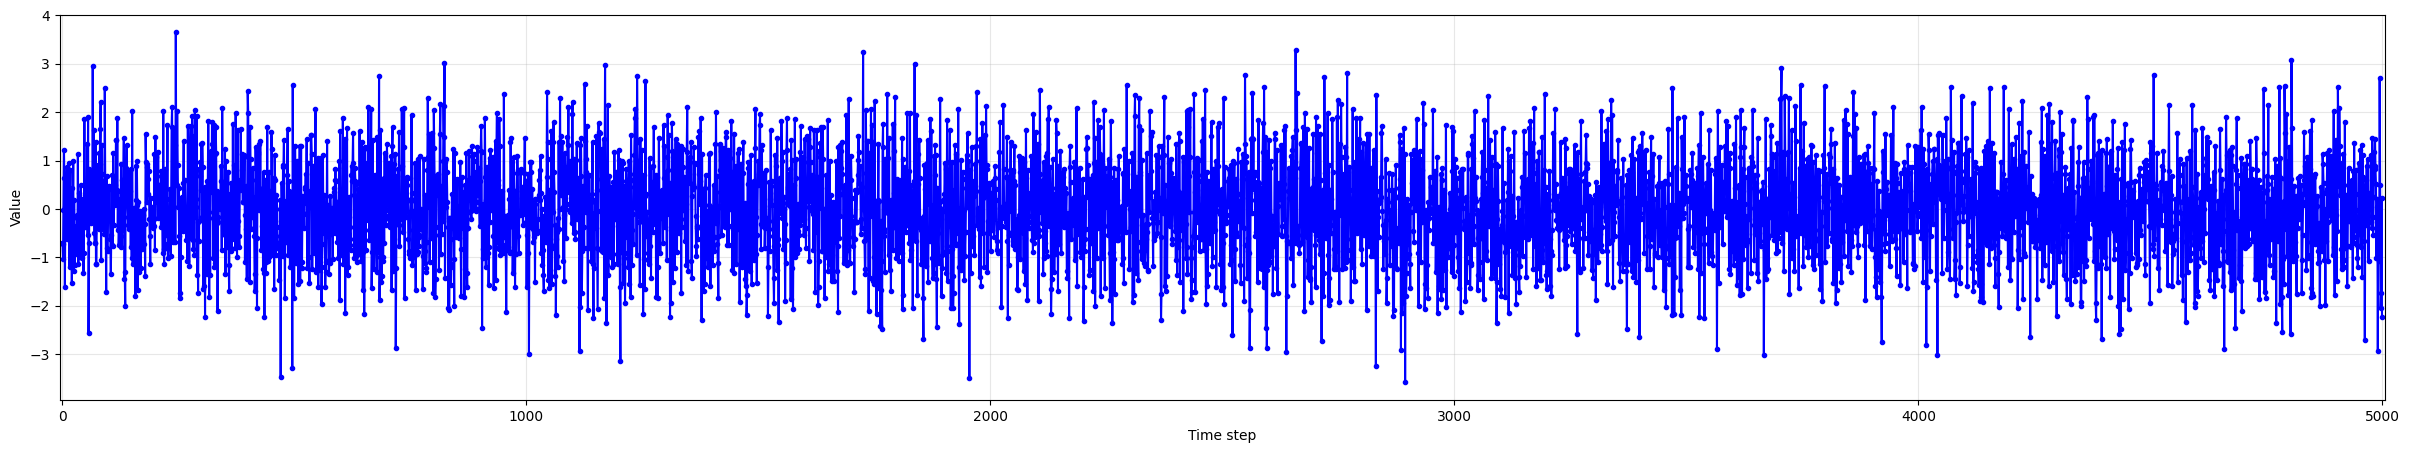

/Users/annanovoksonova/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/module.py:938: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  param_grad = param.grad


Training stopped at step 1468 because MSE exceeded threshold (1000000000000.0).


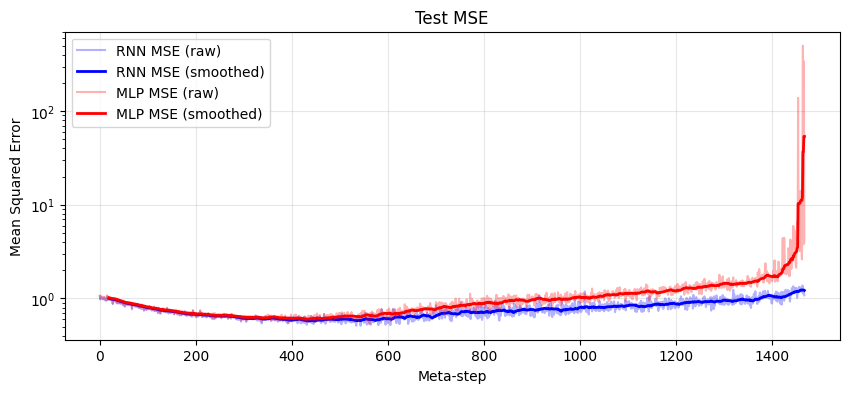

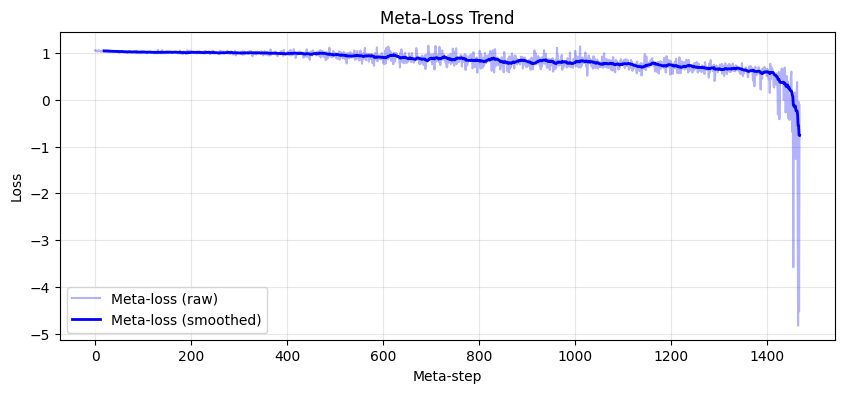

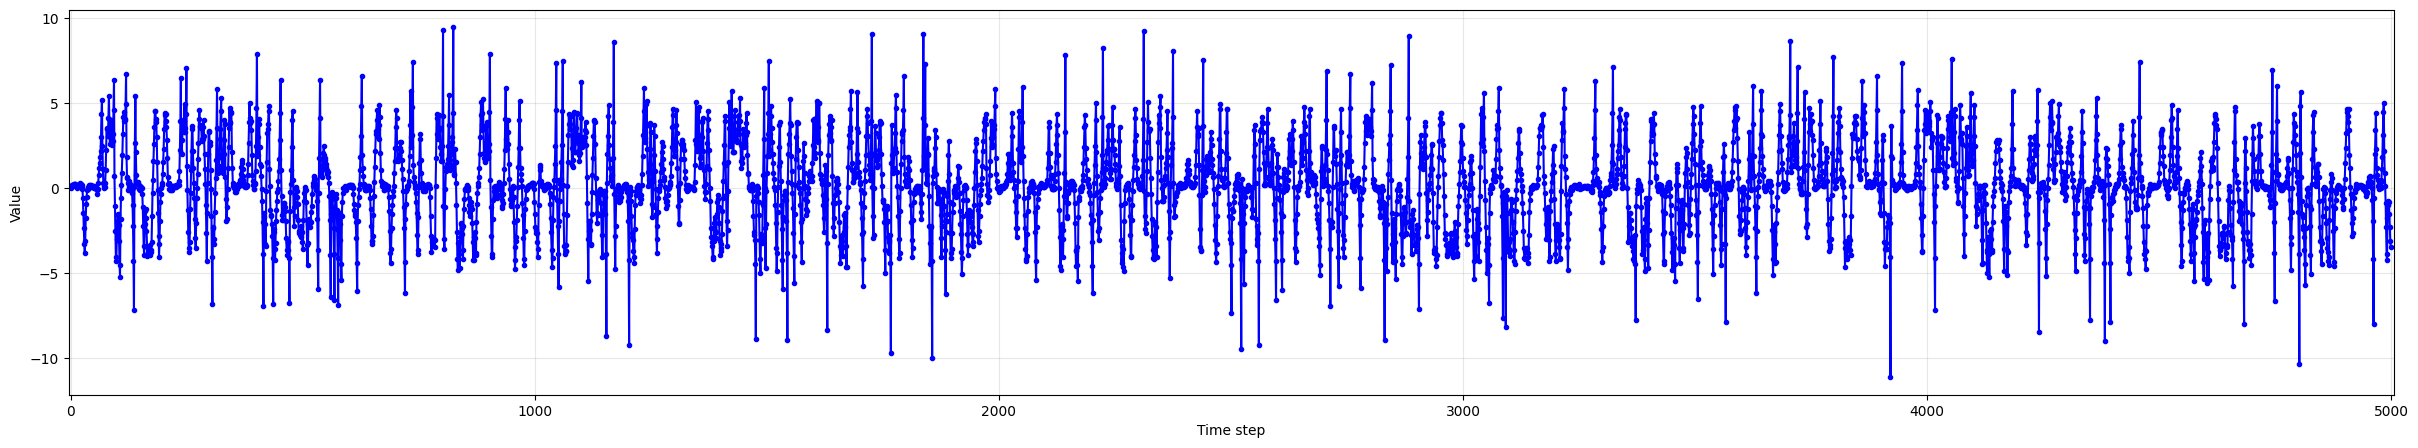

In [8]:
generator = Generator(seq_len=5000)
generator.visualize()
seq_old = generator().detach().cpu().numpy()

meta = MetaLearnerCompetitive(
    generator=generator,
    rnn_class=RNN,
    mlp_class=MLP,
    inner_lr=0.1,
    inner_steps=5,
    meta_lr=0.01,
    reg_lambda=1e-5,
    mlp_lambda=1
)

meta.train(steps=4000, visualize_every=0)
meta.plot_mse(20)
meta.plot_meta_loss(20)
generator.visualize()

/var/folders/79/rtdm6nn16z53c8tt0lqbwx980000gn/T/ipykernel_89815/4018186332.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)


Successful trials: 1000 / 1000
Test MSE (all): 1.131013 ± 0.043275
Test MSE (filtered, 95th percentile): 1.125743 ± 0.037250
Best Test MSE: 1.013081


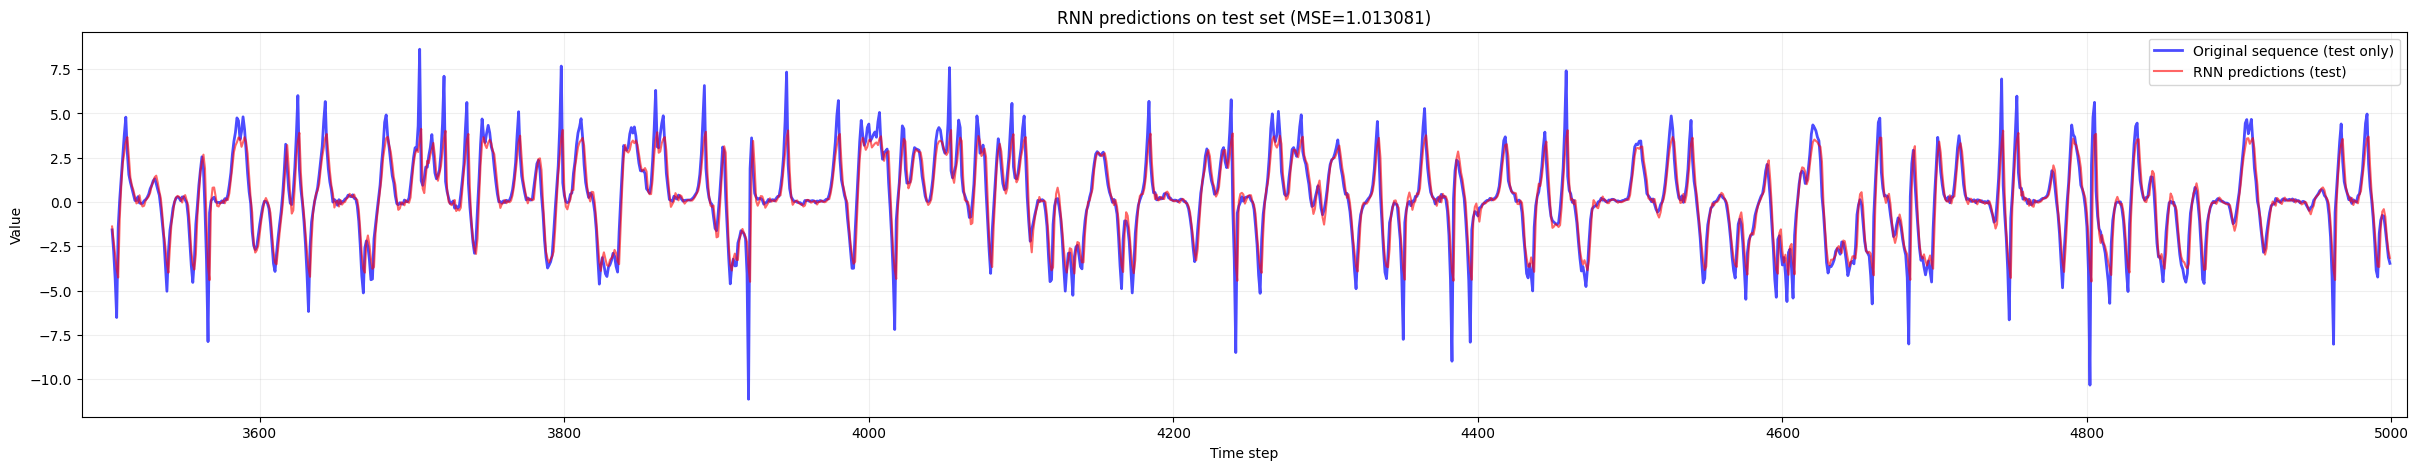

In [9]:
num_trials = 1000
window_size = 10
all_mse = []
best_data = None
best_mse = float('inf')
rnn_best = None

for trial in range(num_trials):
    seq = generator().detach().cpu().numpy()
    seq_len = len(seq)

    X, y = [], []
    for i in range(seq_len - window_size):
        X.append(seq[i : i + window_size])
        y.append(seq[i + window_size])
    X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    split = int(0.7 * len(X))
    X_train, y_train = X[:split], y[:split]
    X_test, y_test = X[split:], y[split:]

    rnn = RNN()
    optimizer = torch.optim.SGD(rnn.parameters(), lr=0.1)
    loss_fn = torch.nn.MSELoss()

    for epoch in range(5):
        optimizer.zero_grad()
        pred = rnn(X_train)[:, -1, :]
        loss = loss_fn(pred, y_train)
        
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Trial {trial}: loss is nan/inf, skipping")
            break
        loss.backward()
        optimizer.step()
    else:
        rnn.eval()
        with torch.no_grad():
            pred_train = rnn(X_train)[:, -1, :]
            pred_test = rnn(X_test)[:, -1, :]
            mse = loss_fn(pred_test, y_test).item()
            
            if np.isfinite(mse):
                all_mse.append(mse)
                
                if mse < best_mse:
                    best_mse = mse
                    rnn_best = rnn
                    best_data = {
                        'seq': seq,
                        'split': split,
                        'window_size': window_size,
                        'x_test': X_test,
                        'y_test': y_test,
                        'pred_test': pred_test
                    }
        continue
    continue

all_mse = np.array(all_mse)
all_mse_filtered = all_mse[all_mse < np.percentile(all_mse, 95)] if len(all_mse) > 0 else []

mean_mse = np.mean(all_mse_filtered) if len(all_mse_filtered) > 0 else float('nan')
std_mse = np.std(all_mse_filtered) if len(all_mse_filtered) > 0 else float('nan')

print(f"Successful trials: {len(all_mse)} / {num_trials}")
print(f"Test MSE (all): {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}" if len(all_mse) > 0 else "No successful trials")
print(f"Test MSE (filtered, 95th percentile): {mean_mse:.6f} ± {std_mse:.6f}")
print(f"Best Test MSE: {best_mse:.6f}")

if best_data is not None:
    test_indices = np.arange(window_size + best_data['split'], 
                              window_size + best_data['split'] + len(best_data['pred_test']))
    
    y_test_true = best_data['y_test'].squeeze().numpy()
    pred_test_values = best_data['pred_test'].squeeze().numpy()

    test_seq = best_data['seq'][window_size + best_data['split']: 
                                 window_size + best_data['split'] + len(pred_test_values)]
    
    plt.figure(figsize=(30, 5))
    plt.plot(test_indices, test_seq, 'b-', linewidth=2, alpha=0.7, label='Original sequence (test only)')
    plt.plot(test_indices, pred_test_values, 'r-', linewidth=1.5, alpha=0.6, label='RNN predictions (test)')
    plt.title(f"RNN predictions on test set (MSE={best_mse:.6f})")
    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.xlim(split - 10, 5010)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
else:
    print("No successful trials to display")

Trial 440: loss is nan/inf, skipping
Successful trials: 961 / 1000
Test MSE (all): 4955180517407609452503236608.000000 ± 151522546138242634366891065344.000000
Test MSE (filtered, 95th percentile): 17600094863824.187500 ± 195984261990787.562500
Best Test MSE: 6.688166


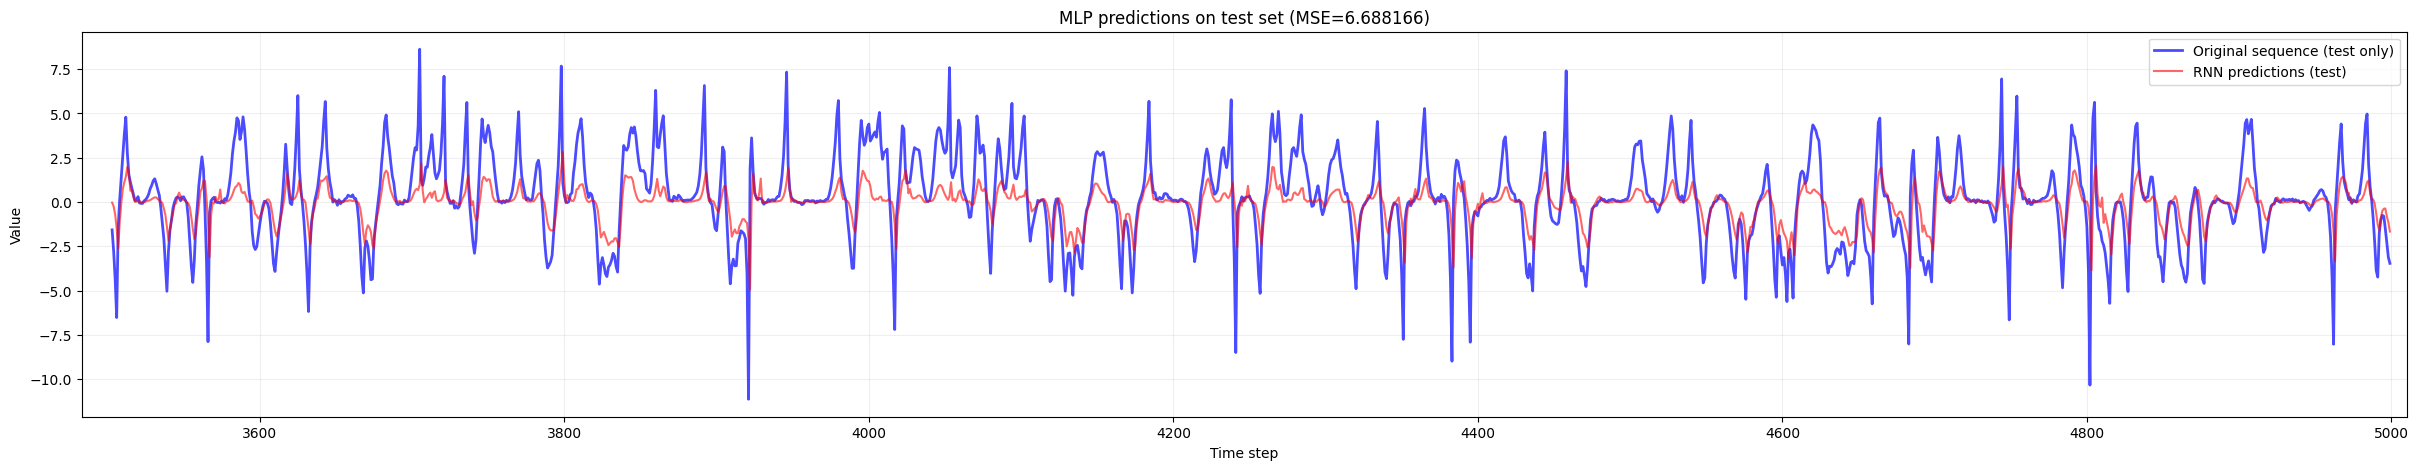

In [12]:
num_trials = 1000
window_size = 10
all_mse = []
best_data = None
best_mse = float('inf')
mlp_best = None

for trial in range(num_trials):
    seq = generator().detach().cpu().numpy()
    seq_len = len(seq)

    X, y = [], []
    for i in range(seq_len - window_size):
        X.append(seq[i : i + window_size])
        y.append(seq[i + window_size])
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    split = int(0.7 * len(X))
    X_train, y_train = X[:split], y[:split]
    X_test, y_test = X[split:], y[split:]

    mlp = MLP(window_size=window_size)
    optimizer = torch.optim.SGD(mlp.parameters(), lr=0.1)
    loss_fn = torch.nn.MSELoss()

    for epoch in range(5):
        optimizer.zero_grad()
        pred = mlp(X_train)[:, -1, :]
        loss = loss_fn(pred, y_train)
        
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Trial {trial}: loss is nan/inf, skipping")
            break
        loss.backward()
        optimizer.step()
    else:
        mlp.eval()
        with torch.no_grad():
            pred_train = mlp(X_train)
            pred_test = mlp(X_test)
            mse = loss_fn(pred_test, y_test).item()
            
            if np.isfinite(mse):
                all_mse.append(mse)
                
                if mse < best_mse:
                    best_mse = mse
                    mlp_best = mlp
                    best_data = {
                        'seq': seq,
                        'pred_train': pred_train,
                        'x_test': X_test,
                        'y_test': y_test,
                        'pred_test': pred_test,
                        'split': split,
                        'window_size': window_size
                    }
        continue
    continue

all_mse = np.array(all_mse)
all_mse_filtered = all_mse[all_mse < np.percentile(all_mse, 95)] if len(all_mse) > 0 else []

mean_mse = np.mean(all_mse_filtered) if len(all_mse_filtered) > 0 else float('nan')
std_mse = np.std(all_mse_filtered) if len(all_mse_filtered) > 0 else float('nan')

print(f"Successful trials: {len(all_mse)} / {num_trials}")
print(f"Test MSE (all): {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}" if len(all_mse) > 0 else "No successful trials")
print(f"Test MSE (filtered, 95th percentile): {mean_mse:.6f} ± {std_mse:.6f}")
print(f"Best Test MSE: {best_mse:.6f}")

if best_data is not None:
    test_indices = np.arange(window_size + best_data['split'], 
                              window_size + best_data['split'] + len(best_data['pred_test']))

    y_test_true = best_data['y_test'].squeeze().numpy()
    pred_test_values = best_data['pred_test'].squeeze().numpy()

    test_seq = best_data['seq'][window_size + best_data['split']: 
                                 window_size + best_data['split'] + len(pred_test_values)]
    
    plt.figure(figsize=(30, 5))
    plt.plot(test_indices, test_seq, 'b-', linewidth=2, alpha=0.7, label='Original sequence (test only)')
    plt.plot(test_indices, pred_test_values, 'r-', linewidth=1.5, alpha=0.6, label='RNN predictions (test)')
    plt.title(f"MLP predictions on test set (MSE={best_mse:.6f})")
    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.xlim(split - 10, 5010)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
else:
    print("No successful trials to display")

Successful trials: 1000 / 1000
Test MSE (all): 1.309462 ± 0.063546
Test MSE (filtered, 95th percentile): 1.301608 ± 0.054320
Best Test MSE: 1.142529


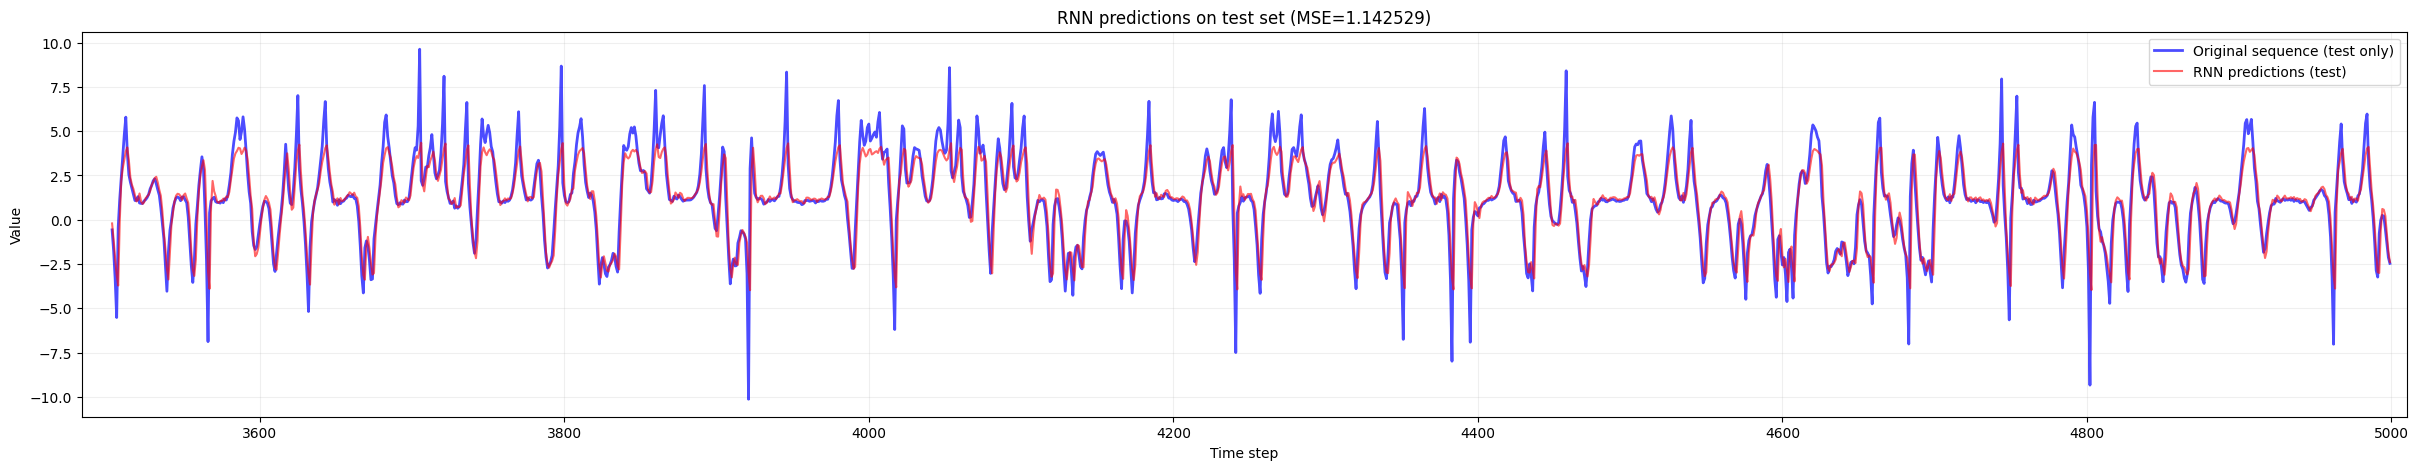

In [20]:
num_trials = 1000
window_size = 10
all_mse = []
best_data = None
best_mse = float('inf')
rnn_best = None
shift = 1.0

for trial in range(num_trials):
    seq = generator().detach().cpu().numpy()
    seq_len = len(seq)

    X, y = [], []
    for i in range(seq_len - window_size):
        X.append(seq[i : i + window_size])
        y.append(seq[i + window_size])
    X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    split = int(0.7 * len(X))
    X_train, y_train = X[:split], y[:split]
    X_test, y_test = X[split:], y[split:]
    X_test = X_test + shift
    y_test = y_test + shift

    rnn = RNN()
    optimizer = torch.optim.SGD(rnn.parameters(), lr=0.1)
    loss_fn = torch.nn.MSELoss()

    for epoch in range(5):
        optimizer.zero_grad()
        pred = rnn(X_train)[:, -1, :]
        loss = loss_fn(pred, y_train)
        
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Trial {trial}: loss is nan/inf, skipping")
            break
        loss.backward()
        optimizer.step()
    else:
        rnn.eval()
        with torch.no_grad():
            pred_train = rnn(X_train)[:, -1, :]
            pred_test = rnn(X_test)[:, -1, :]
            mse = loss_fn(pred_test, y_test).item()
            
            if np.isfinite(mse):
                all_mse.append(mse)
                
                if mse < best_mse:
                    best_mse = mse
                    rnn_best = rnn
                    best_data = {
                        'seq': seq,
                        'split': split,
                        'window_size': window_size,
                        'x_test': X_test,
                        'y_test': y_test,
                        'pred_test': pred_test
                    }
        continue
    continue

all_mse = np.array(all_mse)
all_mse_filtered = all_mse[all_mse < np.percentile(all_mse, 95)] if len(all_mse) > 0 else []

mean_mse = np.mean(all_mse_filtered) if len(all_mse_filtered) > 0 else float('nan')
std_mse = np.std(all_mse_filtered) if len(all_mse_filtered) > 0 else float('nan')

print(f"Successful trials: {len(all_mse)} / {num_trials}")
print(f"Test MSE (all): {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}" if len(all_mse) > 0 else "No successful trials")
print(f"Test MSE (filtered, 95th percentile): {mean_mse:.6f} ± {std_mse:.6f}")
print(f"Best Test MSE: {best_mse:.6f}")

if best_data is not None:
    test_indices = np.arange(window_size + best_data['split'], 
                              window_size + best_data['split'] + len(best_data['pred_test']))
    
    y_test_true = best_data['y_test'].squeeze().numpy()
    pred_test_values = best_data['pred_test'].squeeze().numpy()
    
    test_seq = best_data['seq'][window_size + best_data['split']: 
                                 window_size + best_data['split'] + len(pred_test_values)] + shift
    
    plt.figure(figsize=(30, 5))
    plt.plot(test_indices, test_seq, 'b-', linewidth=2, alpha=0.7, label='Original sequence (test only)')
    plt.plot(test_indices, pred_test_values, 'r-', linewidth=1.5, alpha=0.6, label='RNN predictions (test)')
    plt.title(f"RNN predictions on test set (MSE={best_mse:.6f})")
    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.xlim(split - 10, 5010)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
else:
    print("No successful trials to display")

In [21]:
def check_1(generator, rnn_class, window_size=10, train_ratio=0.7, num_trials=30):
    seq = generator().detach()
    
    def get_mse(data, shuffle=False):
        if shuffle:
            perm = torch.randperm(len(data))
            data = data[perm]
        
        windows, targets = [], []
        for i in range(len(data) - window_size):
            windows.append(data[i : i + window_size])
            targets.append(data[i + window_size])
        
        X = torch.stack(windows).unsqueeze(-1)
        Y = torch.stack(targets).unsqueeze(-1).unsqueeze(-1)
        
        split = int(len(X) * train_ratio)
        X_train, Y_train = X[:split], Y[:split]
        X_test, Y_test = X[split:], Y[split:]
        
        all_mse = []
        
        for _ in range(num_trials):
            model = rnn_class()
            optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
            
            for _ in range(5):
                optimizer.zero_grad()
                pred = model(X_train)[:, -1:, :]
                loss = F.mse_loss(pred, Y_train)
                
                if torch.isnan(loss) or torch.isinf(loss):
                    break
                loss.backward()
                optimizer.step()
            else:
                with torch.no_grad():
                    pred_test = model(X_test)[:, -1:, :]
                    mse = F.mse_loss(pred_test, Y_test).item()
                    if np.isfinite(mse):
                        all_mse.append(mse)
        
        if len(all_mse) == 0:
            return float('nan'), 0
        
        return np.mean(all_mse), np.std(all_mse)
    
    mse_orig_mean, mse_orig_std = get_mse(seq, shuffle=False)
    mse_shuf_mean, mse_shuf_std = get_mse(seq, shuffle=True)
    
    print(f"Original data:   {mse_orig_mean:.6f} ± {mse_orig_std:.6f}")
    print(f"Shuffled data:   {mse_shuf_mean:.6f} ± {mse_shuf_std:.6f}")
    print(f"Difference:      {mse_shuf_mean - mse_orig_mean:.6f}")
    
    return mse_orig_mean, mse_orig_std, mse_shuf_mean, mse_shuf_std

mse_orig_mean, mse_orig_std, mse_shuf_mean, mse_shuf_std = check_1(generator, RNN, num_trials=1000)

Original data:   1.131763 ± 0.043567
Shuffled data:   5.973320 ± 0.004131
Difference:      4.841557


In [22]:
def shuffle_within_windows(X):
    batch_size, window_size, feat_dim = X.shape
    X_shuffled = X.clone()
    
    for i in range(batch_size):
        perm = torch.randperm(window_size)
        X_shuffled[i] = X[i][perm]
    
    return X_shuffled

def check_2(generator, rnn_class, window_size=10, train_ratio=0.7, num_trials=30):
    seq = generator().detach()
    
    windows, targets = [], []
    for i in range(len(seq) - window_size):
        windows.append(seq[i : i + window_size])
        targets.append(seq[i + window_size])
    
    X = torch.stack(windows).unsqueeze(-1)
    Y = torch.stack(targets).unsqueeze(-1).unsqueeze(-1)
    
    split = int(len(X) * train_ratio)
    X_train, Y_train = X[:split], Y[:split]
    X_test, Y_test = X[split:], Y[split:]
    
    all_mse_original = []
    all_mse_shuffled = []
    
    for trial in range(num_trials):
        model = rnn_class()
        optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
        
        for epoch in range(5):
            optimizer.zero_grad()
            pred = model(X_train)[:, -1:, :]
            loss = F.mse_loss(pred, Y_train)
            
            if torch.isnan(loss) or torch.isinf(loss):
                break
            loss.backward()
            optimizer.step()
        else:
            model.eval()
            with torch.no_grad():
                pred_test = model(X_test)[:, -1:, :]
                mse_original = F.mse_loss(pred_test, Y_test).item()

                X_test_shuffled = shuffle_within_windows(X_test)
                pred_test_shuffled = model(X_test_shuffled)[:, -1:, :]
                mse_shuffled = F.mse_loss(pred_test_shuffled, Y_test).item()
                
                if np.isfinite(mse_original) and np.isfinite(mse_shuffled):
                    all_mse_original.append(mse_original)
                    all_mse_shuffled.append(mse_shuffled)
            continue
        continue
    
    if len(all_mse_original) == 0:
        print("No successful trials")
        return None
    
    mean_orig = np.mean(all_mse_original)
    std_orig = np.std(all_mse_original)
    mean_shuf = np.mean(all_mse_shuffled)
    std_shuf = np.std(all_mse_shuffled)
    
    print(f"Original test MSE:   {mean_orig:.6f} ± {std_orig:.6f}")
    print(f"Shuffled test MSE:   {mean_shuf:.6f} ± {std_shuf:.6f}")
    print(f"Difference:          {mean_shuf - mean_orig:.6f}")
    
    return mean_orig, std_orig, mean_shuf, std_shuf

mean_orig, std_orig, mean_shuf, std_shuf = check_2(generator, RNN, window_size=10, num_trials=1000)

Original test MSE:   1.130605 ± 0.045284
Shuffled test MSE:   7.207846 ± 0.264863
Difference:          6.077241


In [35]:
def plot_mse_vs_context_length(generator, trained_model, max_length=15, n_samples=50):
    seq = generator().detach()
    split = int(0.7 * len(seq))
    test_seq = seq[split:]
    
    lengths = list(range(1, max_length + 1))
    means = []
    medians = []
    lower_quantiles = []
    upper_quantiles = []

    trained_model.eval()
    with torch.no_grad():
        for length in lengths:
            current_mses = []
 
            for _ in range(n_samples):
                max_start = len(test_seq) - length - 1
                if max_start <= 0: 
                    continue

                start = np.random.randint(0, max_start)
                
                x = test_seq[start : start + length].view(1, length, 1)
                y = test_seq[start + length].view(1, 1, 1)
                
                pred = trained_model(x)[:, -1:, :]
                mse = F.mse_loss(pred, y).item()
                current_mses.append(mse)
            
            if current_mses:
                means.append(np.mean(current_mses))
                medians.append(np.median(current_mses))
                lower_quantiles.append(np.percentile(current_mses, 25))
                upper_quantiles.append(np.percentile(current_mses, 75))
            else:
                means.append(np.nan)
                medians.append(np.nan)
                lower_quantiles.append(np.nan)
                upper_quantiles.append(np.nan)

    plt.figure(figsize=(10, 5))
    
    lengths_clean = [l for l, low in zip(lengths, lower_quantiles) if not np.isnan(low)]
    lower_clean = [low for low in lower_quantiles if not np.isnan(low)]
    upper_clean = [up for up in upper_quantiles if not np.isnan(up)]
    mean_clean = [m for m in means if not np.isnan(m)]
    median_clean = [m for m in medians if not np.isnan(m)]
    
    if lengths_clean:
        plt.fill_between(lengths_clean, lower_clean, upper_clean, alpha=0.3, color='gray', label='IQR (25%-75%)')
        plt.plot(lengths_clean, mean_clean, linestyle='-', color='blue', linewidth=2, label='Mean')
        plt.plot(lengths_clean, median_clean, linestyle='-', color='red', linewidth=2, label='Median')
    
    plt.xlabel("Context Length", fontsize=12)
    plt.ylabel("Squared Error", fontsize=12)
    plt.title("Dependence of Squared Error on Context Length")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    return lengths, means, medians, lower_quantiles, upper_quantiles

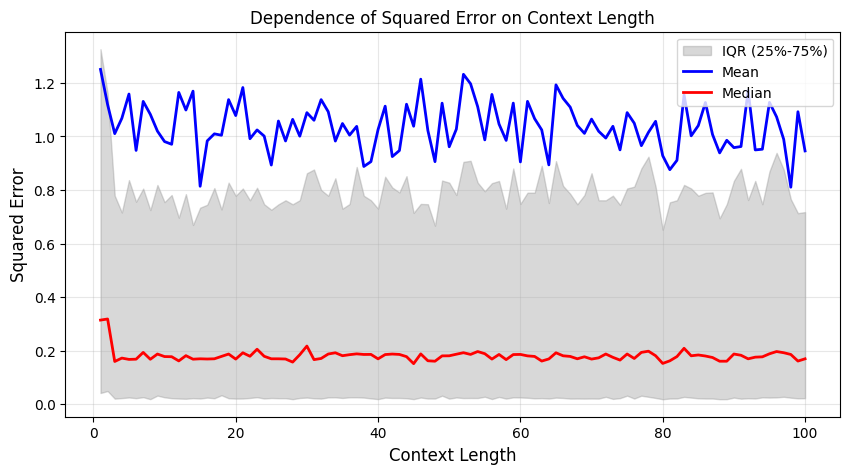

In [36]:
lengths, means, medians, lower_quantiles, upper_quantiles = plot_mse_vs_context_length(generator, rnn_best, 100, 1500)